In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [118]:
df = sns.load_dataset("titanic")

In [119]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [120]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [122]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [123]:
df.shape

(891, 15)

In [124]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [125]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [126]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [127]:
missing = df.isnull().sum()
missing[missing > 0]

,0
age,177
embarked,2
deck,688
embark_town,2


## calculate percentage

In [128]:
missing_percentage = df.isnull().mean() * 100
missing_percentage[missing_percentage > 0].sort_values(ascending = False)

,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


### What is Data Imputation?

Data imputation means replacing missing values (NaN) with reasonable values instead of deleting the rows or columns.

In [129]:
df["age"] = df["age"].fillna(df["age"].median())

In [130]:
df["age"].isnull().sum()

np.int64(0)

In [131]:
df["embarked"].isnull().sum()

np.int64(2)

In [132]:
df["embarked"] = df["embarked"].fillna(
    df["embarked"].mode()[0]
)

In [133]:
df["embarked"].isnull().sum()

np.int64(0)

In [134]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


### duplicate records

In [135]:
df.duplicated().sum()

np.int64(110)

In [136]:
# remove duplicates
df = df.drop_duplicates()

### Filtering

In [137]:
df[df["age"]>50]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
15,1,2,female,55.0,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,1,1,female,52.0,1,1,93.5000,S,First,woman,False,B,Southampton,yes,False
829,1,1,female,62.0,0,0,80.0000,S,First,woman,False,B,NaN,yes,True
851,0,3,male,74.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
857,1,1,male,51.0,0,0,26.5500,S,First,man,True,E,Southampton,yes,True


In [138]:
df[df["sex"] == "female"]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [139]:
df[
    (df["sex"] == "female") &
    (df["survived"] == 1)
]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,1,2,female,28.0,1,0,24.0000,C,Second,woman,False,NaN,Cherbourg,yes,False
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False


In [140]:
df[df["pclass"].isin([1, 2])]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [141]:
df[df["pclass"].between(20, 40)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


In [142]:
df.sort_values(
    ["pclass", "fare"],
    ascending = True
)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
263,0,1,male,40.0,0,0,0.0000,S,First,man,True,B,Southampton,no,True
633,0,1,male,28.0,0,0,0.0000,S,First,man,True,NaN,Southampton,no,True
806,0,1,male,39.0,0,0,0.0000,S,First,man,True,A,Southampton,no,True
815,0,1,male,28.0,0,0,0.0000,S,First,man,True,B,Southampton,no,True
822,0,1,male,38.0,0,0,0.0000,S,First,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,0,3,male,28.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,no,True
509,1,3,male,26.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
643,1,3,male,28.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
159,0,3,male,28.0,8,2,69.5500,S,Third,man,True,NaN,Southampton,no,False


### Adding column

In [143]:
df['country']= "Nepal"

In [144]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'country'],
      dtype='object')

In [145]:
df["country"].isnull().sum()

np.int64(0)

In [146]:
df["country"].duplicated()

,country
0,False
1,True
2,True
3,True
4,True
...,...
885,True
887,True
888,True
889,True


In [147]:
df = df.drop('country', axis =1)

In [148]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Adding rows

In [149]:
df.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False


In [150]:
new_passenger = {
    "passengerId": 892,
    "survived": 1,
    "pclass": 1,
    "sex": "male",
    "age": 22,
    "sibSp": 0,
    "parch": 0,
    "fare": 100,
    "embarked": "S",
    "class": "First",
    "who": "man",
    "adult_male": True,
    "deck": np.nan,
    "embark_town": "Southampton",
    "alive": "yes",
    "alone": True,
    "Has_Sex": True

}

df.loc[len(df)] = new_passenger

In [151]:
new_passenger

{'passengerId': 892,
 'survived': 1,
 'pclass': 1,
 'sex': 'male',
 'age': 22,
 'sibSp': 0,
 'parch': 0,
 'fare': 100,
 'embarked': 'S',
 'class': 'First',
 'who': 'man',
 'adult_male': True,
 'deck': nan,
 'embark_town': 'Southampton',
 'alive': 'yes',
 'alone': True,
 'Has_Sex': True}

In [152]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
885,0,3,female,39.0,0.0,5,29.125,Q,Third,woman,False,NaN,Queenstown,no,False
887,1,1,female,19.0,0.0,0,30.000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1.0,2,23.450,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0.0,0,30.000,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0.0,0,7.750,Q,Third,man,True,NaN,Queenstown,no,True


In [153]:
df["age"].mean()

np.float64(29.62921895006402)

<Axes: ylabel='Frequency'>

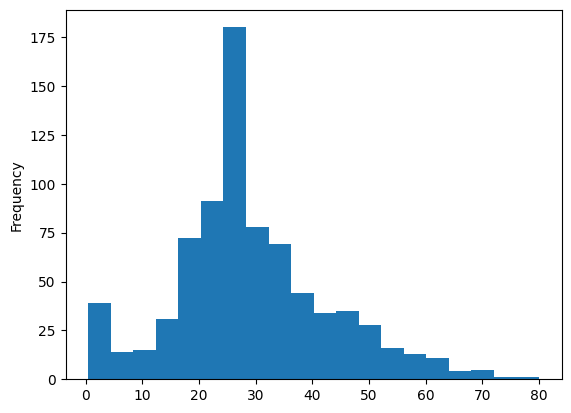

In [154]:
df.age.plot.hist(bins =20)

### Groupby
Divide the data into groups based on one or more columns, then perform an operation on each group.

In [155]:
# average age by gender
df.groupby("sex")["age"].mean()

,age
sex,
female,27.990582
male,30.607710


In [156]:
df.columns


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [157]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,1
parch,0
fare,0
embarked,0
class,0
who,0


In [158]:
df["Has_Sex"] = df["sex"].notna().astype(bool)

In [159]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'Has_Sex'],
      dtype='object')

In [160]:
df["Has_Sex"].head(30)

,Has_Sex
0,True
1,True
2,True
3,True
4,True
5,True
6,True
7,True
8,True
9,True
